# Sample 6 — Mini-GPT: training and generation

Everything from `sample-1` through `sample-5` assembled into one small, trainable, decoder-only
transformer — the same architecture family as GPT — trained on real text, and then used to
**generate** new text one token at a time. This last part is what "inference" means for a
language model: repeatedly predicting the next token and feeding it back in.

**Goals**
1. Stack `sample-5`'s causal `TransformerBlock` into a full character-level language model.
2. Train it on a small embedded corpus and watch the loss drop.
3. Generate text with three decoding strategies: greedy, temperature sampling, top-k sampling.
4. See *why* production inference servers use a KV cache, with a direct demonstration.


## 1. Corpus

A handful of public-domain nursery rhymes, repeated a few times so the tiny model gets enough
exposure to learn their structure. No dataset download — the text is embedded right here. It's
small and repetitive on purpose: this is a teaching model, not a general-purpose one, and this
corpus is enough for it to learn recognizable character-level patterns in a couple of minutes on
a CPU.

In [1]:
rhyme = """twinkle twinkle little star
how i wonder what you are
up above the world so high
like a diamond in the sky

twinkle twinkle little star
how i wonder what you are

humpty dumpty sat on a wall
humpty dumpty had a great fall
all the kings horses and all the kings men
could not put humpty together again

jack and jill went up the hill
to fetch a pail of water
jack fell down and broke his crown
and jill came tumbling after

baa baa black sheep have you any wool
yes sir yes sir three bags full
one for the master one for the dame
one for the little boy who lives down the lane

hickory dickory dock the mouse ran up the clock
the clock struck one the mouse ran down
hickory dickory dock

mary had a little lamb its fleece was white as snow
and everywhere that mary went the lamb was sure to go

row row row your boat gently down the stream
merrily merrily merrily merrily life is but a dream
"""

corpus = (rhyme.strip() + "\n\n") * 8
print(f"corpus length: {len(corpus)} characters")
print(corpus[:120] + "...")


corpus length: 7136 characters
twinkle twinkle little star
how i wonder what you are
up above the world so high
like a diamond in the sky

twinkle twin...


## 2. Character-level tokenizer

Same idea as `sample-1`'s character tokenizer: the vocabulary is every unique character that
appears in the corpus.

In [2]:
chars = sorted(set(corpus))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[i] for i in ids)

print(f"vocab_size: {vocab_size}")
print("vocab:", "".join(chars).replace("\n", "\\n"))


vocab_size: 25
vocab: \n abcdefghijklmnoprstuvwy


In [3]:
import torch

data = torch.tensor(encode(corpus), dtype=torch.long)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"{len(train_data)} training chars, {len(val_data)} validation chars")


6422 training chars, 714 validation chars


## 3. Batching: next-character prediction

Training a language model is a supervised problem in disguise: for every position in the text,
predict the *next* character. A training example is a random `block_size`-character window `x`,
paired with the same window shifted one character to the right, `y`.

In [4]:
torch.manual_seed(0)

block_size = 64   # max context length the model can attend over
batch_size = 32

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x, y

xb, yb = get_batch("train")
print("xb shape:", xb.shape, " yb shape:", yb.shape)
print("\nexample input :", repr(decode(xb[0].tolist())))
print("example target:", repr(decode(yb[0].tolist())), " (same text, shifted one character later)")


xb shape: torch.Size([32, 64])  yb shape: torch.Size([32, 64])

example input : 'bags full\none for the master one for the dame\none for the little'
example target: 'ags full\none for the master one for the dame\none for the little '  (same text, shifted one character later)


## 4. The model

The same building blocks as `sample-5`: multi-head attention (with a causal mask, so token `i`
can't see tokens after it) inside a `TransformerBlock`, stacked `n_layer` times. Two new pieces
wrap it into a full language model:

- A **positional embedding table** (`nn.Embedding`, one learned vector per position) — a
  *learned* alternative to `sample-2`'s fixed sinusoidal formula, the choice GPT-style models make.
- An **output head**, a linear layer mapping each position's final vector to a score
  ("logit") for every character in the vocabulary — the model's prediction for "what comes next".

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self._last_K, self._last_V = None, None  # kept around for the KV-cache demo later

    def split_heads(self, x):
        b, t, d = x.shape
        return x.view(b, t, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        b, h, t, dk = x.shape
        return x.transpose(1, 2).reshape(b, t, h * dk)

    def forward(self, x, mask=None):
        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))
        self._last_K, self._last_V = K.detach(), V.detach()

        scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores + mask
        weights = torch.softmax(scores, dim=-1)
        return self.W_O(self.combine_heads(weights @ V)), weights


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_out, weights = self.attn(x, mask=mask)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn(x))
        return x, weights


In [6]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, block_size, d_model, num_heads, d_ff, n_layer):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList(TransformerBlock(d_model, num_heads, d_ff) for _ in range(n_layer))
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None):
        b, t = idx.shape
        pos = torch.arange(t, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)[None, :, :]

        mask = torch.triu(torch.full((t, t), float("-inf"), device=idx.device), diagonal=1)
        for block in self.blocks:
            x, _ = block(x, mask=mask)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


torch.manual_seed(0)
model = MiniGPT(vocab_size, block_size, d_model=64, num_heads=4, d_ff=256, n_layer=3)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")


157,401 parameters


## 5. Training loop

Standard supervised training: sample a batch, run the model, compute cross-entropy loss between
predicted next-character logits and the actual next characters, backpropagate, step the
optimizer. Every so often we check the loss on held-out validation text too, to make sure the
model is learning the *structure* of the rhymes and not just memorizing noise.

In [7]:
@torch.no_grad()
def estimate_loss(iters=20):
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(iters)
        for k in range(iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

max_iters = 1500
eval_every = 150
train_losses = []

for it in range(max_iters):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if it % eval_every == 0 or it == max_iters - 1:
        losses = estimate_loss()
        print(f"step {it:4d}: train loss {losses['train']:.3f}, val loss {losses['val']:.3f}")


step    0: train loss 3.025, val loss 3.023


step  150: train loss 0.554, val loss 0.592


step  300: train loss 0.127, val loss 0.134


step  450: train loss 0.101, val loss 0.106


step  600: train loss 0.087, val loss 0.089


...

step  900: train loss 0.084, val loss 0.084


step 1050: train loss 0.078, val loss 0.080


step 1200: train loss 0.077, val loss 0.076


step 1350: train loss 0.085, val loss 0.092


step 1499: train loss 0.076, val loss 0.077


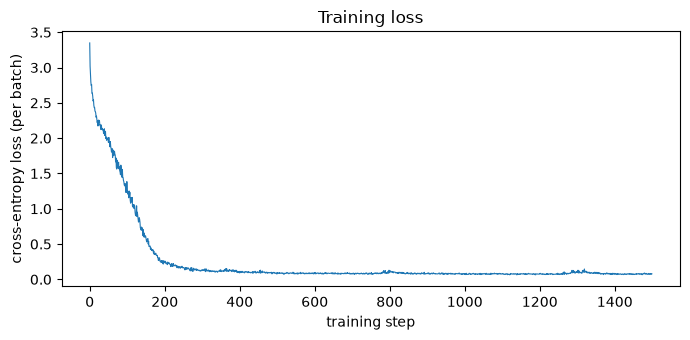

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.plot(train_losses, linewidth=0.8)
plt.xlabel("training step")
plt.ylabel("cross-entropy loss (per batch)")
plt.title("Training loss")
plt.tight_layout()
plt.show()


## 6. Inference: generating text

Training predicts one next-character distribution per position, all at once, in parallel — that
works because we already know the whole sequence. **Generation is different**: we only have a
prompt, and have to predict one character, append it, and repeat, since each new character
depends on everything generated so far. This is why generation is fundamentally *sequential*,
even though training was parallel.

Three ways to turn the model's predicted probabilities into an actual next character:

- **Greedy**: always pick the single highest-probability character. Deterministic, but repetitive.
- **Temperature sampling**: divide the logits by a temperature `T` before softmax, then sample
  from the resulting distribution. `T < 1` sharpens it (closer to greedy); `T > 1` flattens it
  (more random).
- **Top-k sampling**: zero out every character except the `k` most likely ones, then sample from
  what's left — avoids both "always the same answer" and "occasionally something wildly off".

In [9]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens, temperature=1.0, top_k=None):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]                 # crop to the model's max context
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]                        # only the *last* position's prediction

        if temperature == 0:                              # greedy: skip scaling and sampling
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float("-inf")  # mask everything outside the top k
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())


In [10]:
prompt = "twinkle twinkle"
torch.manual_seed(1)

print("GREEDY (temperature=0):\n", generate(model, prompt, 80, temperature=0), "\n")
print("TEMPERATURE SAMPLING (T=0.8):\n", generate(model, prompt, 80, temperature=0.8), "\n")
print("TOP-K SAMPLING (k=5, T=0.8):\n", generate(model, prompt, 80, temperature=0.8, top_k=5), "\n")
print("TEMPERATURE SAMPLING (T=1.5, no top-k):\n", generate(model, prompt, 80, temperature=1.5))


GREEDY (temperature=0):
 twinkle twinkle little star
how i wonder what you are

humpty dumpty sat on a wall
humpty dumpt 

TEMPERATURE SAMPLING (T=0.8):
 twinkle twinkle little star
how i wonder what you are

humpty dumpty sat on a wall
humpty dumpt 

TOP-K SAMPLING (k=5, T=0.8):
 twinkle twinkle little star
how i wonder what you are

humpty dumpty sat on a wall
humpty dumpt 

TEMPERATURE SAMPLING (T=1.5, no top-k):
 twinkle twinkle little star

how i wonder what you are
are
up above the world so high
like a di


The corpus is small and repeated many times, so training pushes the loss very low (below the
loss-curve plot's tail) — the model becomes extremely *confident*, its predicted distribution
collapsing close to one-hot. That's why greedy, `T=0.8`, and top-k all agree here: when one
character dominates the probability mass, every reasonable decoding strategy picks it. Cranking
temperature up to `1.5` flattens the distribution enough to make that visible — expect
recognizable words to start breaking down into less-likely characters. This is the general
pattern: low temperature (or greedy) is safe but repetitive and can loop; high temperature adds
variety but risks incoherence; top-k (and its cousin top-p / nucleus sampling, used by
`sample-7`'s `.generate()`) is the usual compromise — some randomness, but never from the
distribution's unlikely tail.

## 7. Why real inference servers use a KV cache

Look closely at `generate()` above: on *every* new token, it reruns the model on the **entire**
growing prefix (`idx_cond`) from scratch — recomputing `Q`, `K`, `V` for tokens it already
processed on the previous step. That's wasteful, and it's exactly what a **KV cache** eliminates.

It works because of the causal mask: token `i`'s attention output can only ever depend on tokens
`0..i`, never on anything after it. So extending the sequence by one token cannot change the `K`
and `V` vectors already computed for the earlier tokens — they're safe to compute once and reuse.
Let's verify that directly, using the `_last_K`/`_last_V` the attention module stashed during its
last forward pass.

In [11]:
prefix = encode("humpty dumpty sat")
t = len(prefix)

x_t = torch.tensor([prefix])
x_t1 = torch.tensor([prefix + [stoi['o']]])  # same prefix, one extra token appended

model(x_t)
K_t = model.blocks[0].attn._last_K.clone()      # shape (1, num_heads, t, d_k)

model(x_t1)
K_t1 = model.blocks[0].attn._last_K.clone()     # shape (1, num_heads, t+1, d_k)

# K for the *first t* positions should be identical whether or not a t+1-th token was appended
same = torch.allclose(K_t, K_t1[:, :, :t, :])
print(f"K for the first {t} positions unchanged after appending a token: {same}")


K for the first 17 positions unchanged after appending a token: True


They match exactly. A KV cache stores each layer's `K`/`V` for every already-generated token,
so each new generation step only has to compute `Q`, `K`, `V` for the **one new token** and reuse
the cached `K`/`V` for the rest — turning the per-step attention cost from *recompute everything
so far* into *compute one new thing, reuse the rest*. This notebook's `generate()` skips that
optimization for clarity; `sample-7`'s HuggingFace `.generate()` uses a KV cache internally by
default.

**Next:** `sample-7-pretrained-inference-huggingface` steps outside this from-scratch code
entirely and loads a *real* pretrained GPT-2 to compare its tokenizer, architecture, and
generation behavior against everything built here.